# Simple model with Flow Matching

Attempting to do the same thing as in `simple_model.ipynb`, but using Flow Matching instead of MCMC sampling. 

In [ ]:
import sys
sys.path.append('..')

# from src.simulator import BurstSimulator, Model
# from src.flow_matching.distributions import  Prior, Posterior
# from src.flow_matching.probability_path import , GuidedLinearProbabilityPath
# from src.flow_matching.training import  GuidedConditionalFlowMatchingTrainer
# from src.flow_matching.integration import EulerODESolver
# from src.flow_matching.models import  MLPGuidedVectorField, LightCurveThinner
# from src.helpers import record_every, hist2d_samples

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Sampleable, Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath, LinearConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer, GuidedConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPVectorField, MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding
from src.helpers import record_every

import numpy as np
import matplotlib.pyplot as plt
import torch
from corner import corner

from src.flow_matching.plotting import plot_loss, plot_snapshots, hist2d_samples
from src.flow_matching.helpers import choose_device, build_mlp

device = choose_device()

# Example CFM for SBI
Transforming a uniform prior distribution (with enforced order, i.e. $t_1$ < $t_2$>) to a delta function posterior centered on [`true_t0_1`, `true_t0_2`], without the guidance of simulated data. 

In [15]:
# Samplelable posterior 
class DeltaPosterior(Sampleable):

    """
    This is now for a given datapoint, so just samples true_t0_1, true_t0_2.
    Essentially a delta function.
    """
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_1 = 0.1 * torch.ones((num_samples, 1))
        t0_2 = 0.6 * torch.ones((num_samples, 1))
        return torch.cat((t0_1, t0_2), dim=1)

# construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),
    p_data = DeltaPosterior()
).to(device)

# construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[32, 16, 16, 8])

# construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=10000, device=device, lr=1e-3, batch_size=256, save_checkpoint=False)

Training model with size: 0.004 MiB


Epoch 9999, loss: 0.001, lr: 3.11e-05: 100%|██████████| 10000/10000 [01:50<00:00, 90.34it/s]


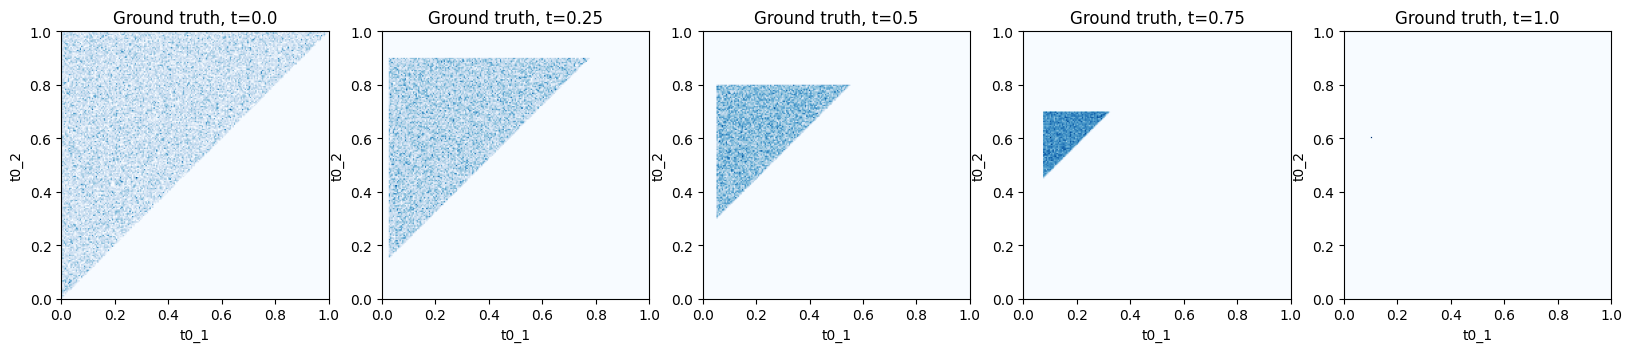

100%|██████████| 99/99 [00:00<00:00, 757.52it/s]


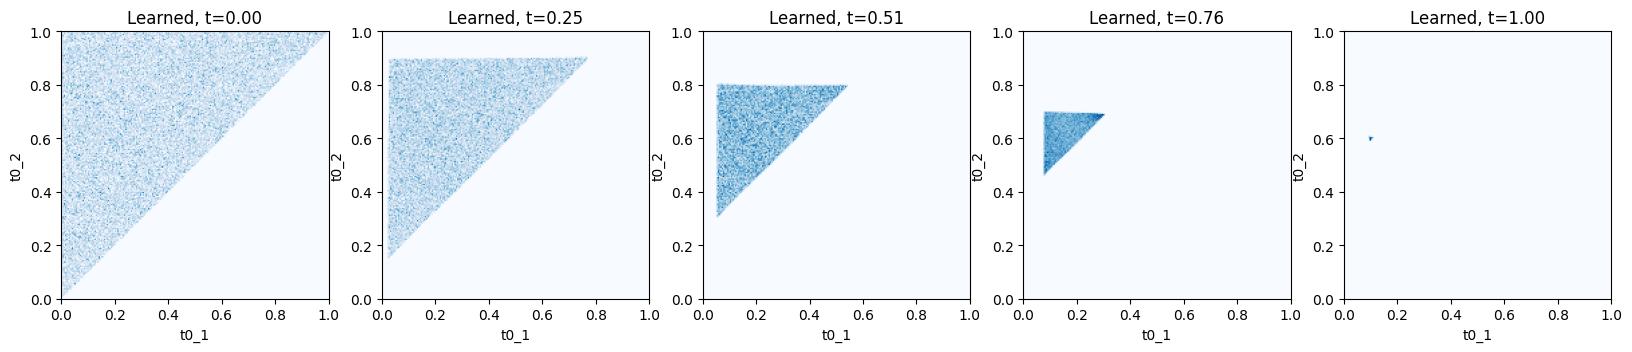

In [16]:
num_samples = 50000  # number of samples per snapshot
num_marginals = 5    # number of snapshots to plot

plt.figure(figsize=(20,10))

# ----------------------------- #
# Graph Ground-Truth Marginals  #
# ----------------------------- #

ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts, range=[[0,1], [0,1]], percentile=100, cmap='Blues')

    plt.title(f"Ground truth, t={t.item()}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
plt.show()

# -----------------------------------------#
# Graph Marginals of Learned Vector Field  #
# -----------------------------------------#

# initialize ODE solver
solver = EulerODESolver(linear_flow_model)
nts = 100
ts = torch.linspace(0, 1, nts).to(device)

# simulate ODE starting from x0
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1))

# only save num_marginals snapshots 
record_every_idxs = record_every(nts, nts // (num_marginals - 1))
xts = xts[:, record_every_idxs, :]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts, ts, record_every_idxs, num_marginals, show=False)


# Adding guiding with simulated data for fixed parameters
Now want to do guided flow matching, meaning the transformation is guided by a sample from the simulated dataset. This means during training we train using sample pairs (p, d) where p are the parameters and d is the corresponding simulated data generated with the simulator with input p. The input of the network in the end will be prior sample p_r, the simulated data and point in time $t\sim U(0, 1)$. The output of the solved ODE with the learned vector field is a sample from the posterior. We have to change several functions to accomodate training pairs (p, d). 

Since the time sequence is quite long, we thin it by only including every 10th bin. This reduces the length from 1000 to 100. Later , we will use a more sophisticated time series encoder. This is also without using any encoding for $\theta$ (the parameter vector) and $\tau$ (flow matching time), meaning they will take up only 3% of the input vector for this specific model.

In [29]:
path = GuidedLinearProbabilityPath(
    p_simple=Prior(),
    p_data=Posterior()
)

latent_dim = 100
time_seq_encoder = LightCurveThinner(latent_dim)

vector_field = MLPGuidedVectorField(dim=2, hiddens=[64, 64, 32, 16], time_dim=latent_dim, time_seq_encoder=time_seq_encoder)

trainer = GuidedConditionalFlowMatchingTrainer(path, vector_field)
losses = trainer.train(2000, device, 5e-4, save_checkpoint=True, batch_size=256)

Training model with size: 0.051 MiB


Epoch 1999, loss: 0.104, lr: 1.60e-05: 100%|██████████| 2000/2000 [03:25<00:00,  9.74it/s]


100%|██████████| 99/99 [00:00<00:00, 1282.18it/s]


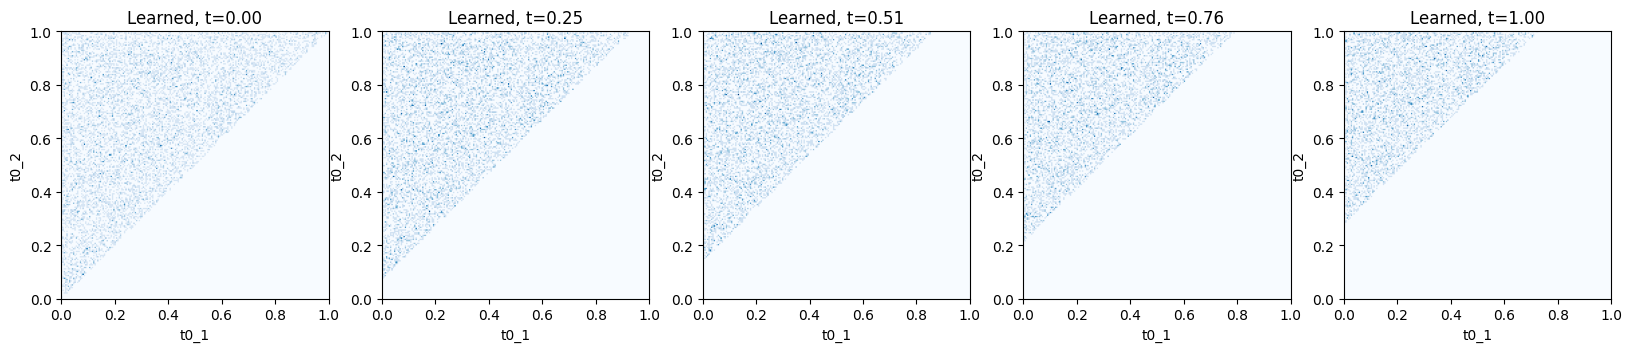

In [ ]:
# --------------------------------------------- #
#   Plot Marginal Path of Learned Vector Field  #
# --------------------------------------------- #

# fixed model parameters (NOTE: Should be same as used during training in Posterior)
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.2, 0.8] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

# generate one instance of simulated data 
model    = Model(time=time, ncomp=N, burstparams=burstparams, ybkg=ybkg)
simulator= BurstSimulator(model)
x_counts = simulator.simulate_burst()

num_samples = 10000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# use same data for all prior samples
simulation_time_resolution = 1000
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(num_samples, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 100
ts = torch.linspace(0, 1, nts).to(device)

# simulate ODE starting from x0
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, nts, 1).expand(num_samples, nts, 1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(nts, nts // (num_marginals - 1))
xts = xts[:, record_every_idxs, :]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts, ts, record_every_idxs, num_marginals, show=False)

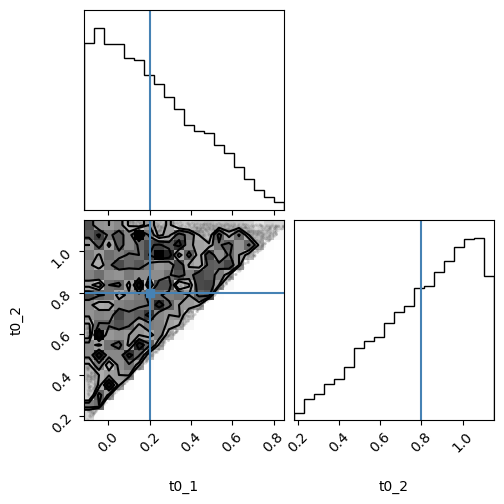

In [31]:
# corner-plot
fig = corner(final_snapshot.cpu().numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))